In [1]:
import os, sys
sys.path.append(os.path.abspath('../..'))
from utlis.sync_utlis.general_loader import load_flat_with_frame_map, merge_pred_with_miniscope
from utlis.sync_utlis.general_loader_viz import plot_two_coms_from_pred_df


oct3v1 = "/data/big_rim/rsync_dcc_sum/Oct3V1"
rec_path = os.path.join(oct3v1, "2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30")
nc_key='wnd1500_stp700_max25_diff3.5_pnr1.1'
dannce_folder='SDANNCE/predict00'


merged = merge_pred_with_miniscope(
    rec_path=rec_path,
    nc_key=nc_key,
    dannce_folder=dannce_folder,
    com_folder=None,
    save_h5=False,
    save_csv=False,
)

merged.shape, merged.index[:3]

((12700, 273), Index([-5, 35, 64], dtype='int64', name='timestamp_ms_mini'))

In [2]:
# from utlis.social_analysis.approaching import get_proximity_rows_by_com, plot_skeleton_frames
# threshold_mm=30.0
# df = merged

# # 1) pick proximity frames by CoM
# rows = get_proximity_rows_by_com(df, threshold_mm=threshold_mm, p1="com1", p2="com2", smooth_window=1)

# # 2) plot first 10 frames; draw snout↔snout, snout↔tail(base), snout↔tail(end)
# plot_skeleton_frames(
#     df,
#     rows,
#     n=10,
#     animal1="a1",
#     animal2="a2",
#     pairs=(("Snout","Snout"), ("Snout","Tail(base)"), ("Snout","Tail(end)")),
#     threshold_mm=threshold_mm,
#     invert_y=False  # set True if your y is image coordinates
# )


In [3]:
from utlis.social_analysis.approaching import compute_com_distance, compute_motion_direction, detect_approaches
# 0) If you want distance only
dist = compute_com_distance(merged, p1="com1", p2="com2", smooth_window=5)
print(dist.head())

# 1) Motion vectors / directions for each animal
m1 = compute_motion_direction(merged, prefix="com1", time_col="timestamp_ms_mini", pos_smooth=5, vel_smooth=5)
m2 = compute_motion_direction(merged, prefix="com2", time_col="timestamp_ms_mini", pos_smooth=5, vel_smooth=5)
print(m1.filter(like="_speed").head(), m2.filter(like="_speed").head())

# 2) Detect approach windows (tune thresholds as you like)
res = detect_approaches(
    merged,
    p1="com1", p2="com2",
    time_col="timestamp_ms_mini",   # if absent, pass fps=...
    pos_smooth=5, vel_smooth=5,
    radial_thresh=20.0,             # mm/s toward the other
    speed_min=5.0,                  # mm/s total speed floor
    dist_min=None,                  # e.g., set 50.0 to ignore near-collisions if needed
    dist_max=300.0,                 # focus on interaction zone
    min_samples=15,                 # ≥15 consecutive frames
    return_intervals=True
)

# Per-frame booleans + metrics
res["frames"][["dist_mm","radial1","radial2","approach1","approach2","mutual"]].head()

# Interval summaries (list of dicts)
res["intervals"]["approach1"][:3], res["intervals"]["approach2"][:3], res["intervals"]["mutual"][:3]


timestamp_ms_mini
-5      50.580713
 35     50.694257
 64     50.803232
 97     50.946379
 130    51.173287
Name: dist_mm, dtype: float64
                   com1_speed
timestamp_ms_mini            
-5                   0.154367
 35                  0.162126
 64                  0.167439
 97                  0.159762
 130                 0.147180                    com2_speed
timestamp_ms_mini            
-5                   0.047668
 35                  0.057717
 64                  0.065080
 97                  0.077614
 130                 0.081325


([], [], [])

In [16]:
def pick_alignment_cols(frames):
    frame_col = None
    for c in ("camera_frame_sixcam", "mapped_sixcam_frame_indices"):
        if c in frames.columns:
            frame_col = c
            break
    mini_ms_col = "timestamp_ms_mini" if "timestamp_ms_mini" in frames.columns else None
    return frame_col, mini_ms_col


def extract_incidents(frames, events, frame_col=None, mini_ms_col=None):
    """
    Turns events into simple per-event lists you can feed to other funcs.
    Returns a list of dicts:
      {"start_idx", "end_idx_exclusive", "index", "sixcam", "mini_ms"}
    Missing cols are omitted.
    """
    out = []
    for ev in events:
        s, e = ev["start_idx"], ev["end_idx_exclusive"]
        sl = slice(s, e)
        item = {
            "start_idx": s,
            "end_idx_exclusive": e,
            "index": frames.index[sl].tolist()
        }
        if frame_col:
            item["sixcam"] = frames.iloc[sl][frame_col].astype(int).tolist()
        if mini_ms_col:
            item["mini_ms"] = frames.iloc[sl][mini_ms_col].astype(float).tolist()
        out.append(item)
    return out


import numpy as np
import matplotlib.pyplot as plt

def plot_dist_with_events(frames, mask, events, contact_mm=50.0, title=None):
    dist = frames["dist_mm"].to_numpy()
    x = frames.index

    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(x, dist, lw=1, label="dist_mm")
    ax.scatter(x[mask], dist[mask], s=8, label="approach_success", zorder=3)
    ax.axhline(contact_mm, ls="--", lw=1, label=f"contact={contact_mm} mm")

    if events:
        contact_idx = np.array([ev["contact_idx"] for ev in events], dtype=int)
        ax.scatter(x[contact_idx], dist[contact_idx], marker="x", s=36, zorder=4, label="first contact")

        # light spans per event (fast; number of events is small)
        for ev in events:
            s, e = ev["start_idx"], ev["end_idx_exclusive"]
            ax.axvspan(x[s], x[e-1], alpha=0.15)

    ax.set_ylabel("distance (mm)")
    ax.set_xlabel("frame")  # or "time" if your index is time-like
    ax.set_title(title or f"Approach-success events (n={len(events)})")
    ax.legend(loc="best")
    plt.tight_layout()
    return fig, ax


# def plot_single_event(frames, ev, contact_mm=50.0):
#     s, e = ev["start_idx"], ev["end_idx_exclusive"]
#     sl = slice(s, e)
#     x = frames.index[sl]
#     dist = frames["dist_mm"].iloc[sl]

#     fig, ax = plt.subplots(figsize=(8, 3))
#     ax.plot(x, dist, lw=1.2)
#     ax.axhline(contact_mm, ls="--", lw=1)
#     # mark first contact if ev has it
#     if "contact_idx" in ev:
#         cx = frames.index[ev["contact_idx"]]
#         ax.scatter([cx], [frames["dist_mm"].iloc[ev["contact_idx"]]], marker="x", s=36, zorder=4)
#     ax.set_ylabel("distance (mm)")
#     ax.set_xlabel("frame")
#     ax.set_title(f"Event [{s}:{e})  drop={ev.get('drop_mm', np.nan):.1f}mm")
#     plt.tight_layout()
#     return fig, ax

def plot_single_event(frames, ev, contact_mm=50.0, mark="both"):
    """
    mark: "contact" | "bottom" | "both"
    """
    s, e = ev["start_idx"], ev["end_idx_exclusive"]
    x = frames.index[s:e]
    dist = frames["dist_mm"].iloc[s:e]

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(x, dist, lw=1.2, zorder=1)
    ax.axhline(contact_mm, ls="--", lw=1, zorder=0)

    # start/end verticals for context
    ax.axvline(frames.index[s], ls=":", lw=1, alpha=0.6, zorder=0)
    ax.axvline(frames.index[e-1], ls=":", lw=1, alpha=0.6, zorder=0)

    if ("contact_idx" in ev) and (mark in {"contact", "both"}):
        ci = ev["contact_idx"]
        ax.scatter([frames.index[ci]], [frames["dist_mm"].iat[ci]],
                   marker="x", s=40, zorder=3, label="first contact")

    if ("bottom_idx" in ev) and (mark in {"bottom", "both"}):
        bi = ev["bottom_idx"]
        ax.scatter([frames.index[bi]], [frames["dist_mm"].iat[bi]],
                   marker="o", s=36, zorder=4, label="bottom (min distance)")

    ax.set_ylabel("distance (mm)")
    ax.set_xlabel("frame")
    ax.set_title(f"Event [{s}:{e})  drop={ev.get('drop_mm', float('nan')):.1f} mm")
    ax.legend(loc="best", frameon=False)
    fig.tight_layout()
    return fig, ax



(<Figure size 1000x350 with 1 Axes>,
 <Axes: title={'center': 'Approach-success (best)'}, xlabel='frame', ylabel='distance (mm)'>)

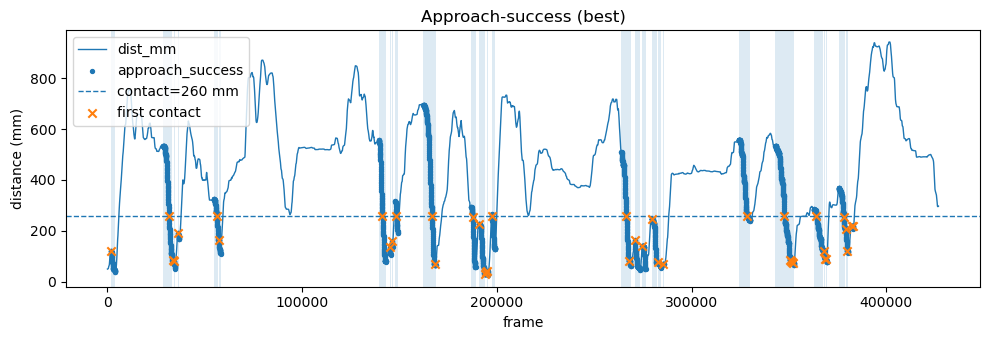

In [ ]:
from utlis.social_analysis.approaching import find_approach_success
contact_mm = 260
# --- choose a setting (use your "best" from the sweep) ---
mask, events = find_approach_success(
    res["frames"],
    contact_mm=contact_mm,
    dD_dt_thresh=0.0,
    min_len=1,
    min_drop_mm=1#10.0
)
frames = res["frames"]

# --- global plot with event spans (uses the helper we wrote) ---

# --- quick QA: first 3 events as small windows ---
# for ev in events[:3]:
#     plot_single_event(frames, ev, contact_mm=contact_mm)




In [14]:
events

[{'start_idx': 57,
  'end_idx_exclusive': 117,
  'contact_idx': 57,
  'bottom_idx': 116,
  'start_dist_mm': 123.24438319872635,
  'contact_dist_mm': 123.24438319872635,
  'min_dist_mm': 39.985986854634035,
  'end_dist_mm': 39.985986854634035,
  'drop_mm': 83.25839634409232,
  'duration_frames_to_contact': 1,
  'duration_frames_total': 60,
  'increasing_guard': {'sep_consec': 2, 'dD_dt_sep_thresh': 0.0}},
 {'start_idx': 852,
  'end_idx_exclusive': 992,
  'contact_idx': 940,
  'bottom_idx': 991,
  'start_dist_mm': 533.7653239513016,
  'contact_dist_mm': 257.943210358974,
  'min_dist_mm': 82.36402643385851,
  'end_dist_mm': 82.36402643385851,
  'drop_mm': 451.40129751744314,
  'duration_frames_to_contact': 89,
  'duration_frames_total': 140,
  'increasing_guard': {'sep_consec': 2, 'dD_dt_sep_thresh': 0.0}},
 {'start_idx': 1002,
  'end_idx_exclusive': 1010,
  'contact_idx': 1002,
  'bottom_idx': 1009,
  'start_dist_mm': 84.40022036048843,
  'contact_dist_mm': 84.40022036048843,
  'min_dist

#approach_success events: 14


100%|██████████| 973/973 [01:35<00:00, 10.17it/s]


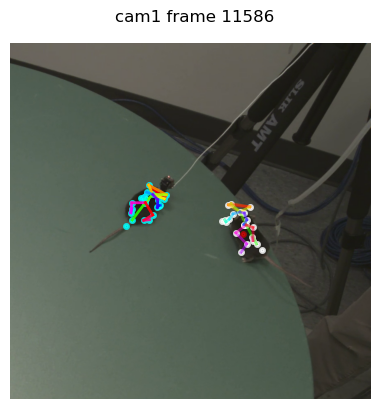

In [27]:
from utlis.social_analysis.approaching import find_approach_success
from utlis.vis_valid_utlis.sdannce_vis import cfg, visualize_frames

C = cfg(base_path="/data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30", cammm=1, 
        enable_zoom=True, zoom_margin=450) #animal="mouse20", #write_pngs=True

# 0) Run your detector first
mask, events = find_approach_success(
    res["frames"],
    contact_mm=150.0,
    dD_dt_thresh=0.0,
    min_len=1,
    min_drop_mm=3#10.0
)

frames = res["frames"]
frame_col = "camera_frame_sixcam" if "camera_frame_sixcam" in frames.columns \
    else ("mapped_sixcam_frame_indices" if "mapped_sixcam_frame_indices" in frames.columns else None)

print(f"#approach_success events: {len(events)}")

incident_all_six_cam = frames.loc[mask, frame_col].astype(int).tolist() if frame_col else frames.index[mask].tolist()

visualize_frames(incident_all_six_cam, config=C, out_name="all_incidents_contact150_dD0_min1d3")

In [ ]:
from utlis.social_analysis.approaching import find_approach_success
from utlis.vis_valid_utlis.sdannce_vis import cfg, visualize_frames

C = cfg(base_path="/data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30", cammm=1, 
        enable_zoom=True, zoom_margin=450) #animal="mouse20", #write_pngs=True

contact_mm= 260.0
# 0) Run your detector first
mask, events = find_approach_success(
    res["frames"],
    contact_mm=contact_mm,
    dD_dt_thresh=0.0,
    min_len=1,
    min_drop_mm=3#10.0
)

frames = res["frames"]
frame_col = "camera_frame_sixcam" if "camera_frame_sixcam" in frames.columns \
    else ("mapped_sixcam_frame_indices" if "mapped_sixcam_frame_indices" in frames.columns else None)

print(f"#approach_success events: {len(events)}")

incident_all_six_cam = frames.loc[mask, frame_col].astype(int).tolist() if frame_col else frames.index[mask].tolist()

visualize_frames(incident_all_six_cam, config=C, out_name=f"all_incidents_contact{contact_mm}_dD0_min1d3")

#approach_success events: 33
